In [33]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib
from numpy import random
from scipy.special import erf
from scipy.optimize import curve_fit
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2
from scipy.stats import cosine, lognorm, skew, kurtosis, gaussian_kde, mode, expon
from scipy.stats import t as student_t
from scipy.stats import f as fisher_f
from scipy.stats import weibull_min
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

In [34]:
#dato u zadatku
data=np.load('sunspot.npz')
B=data['B']
theta=np.degrees(data['inc'])
phi=np.degrees(data['az'])

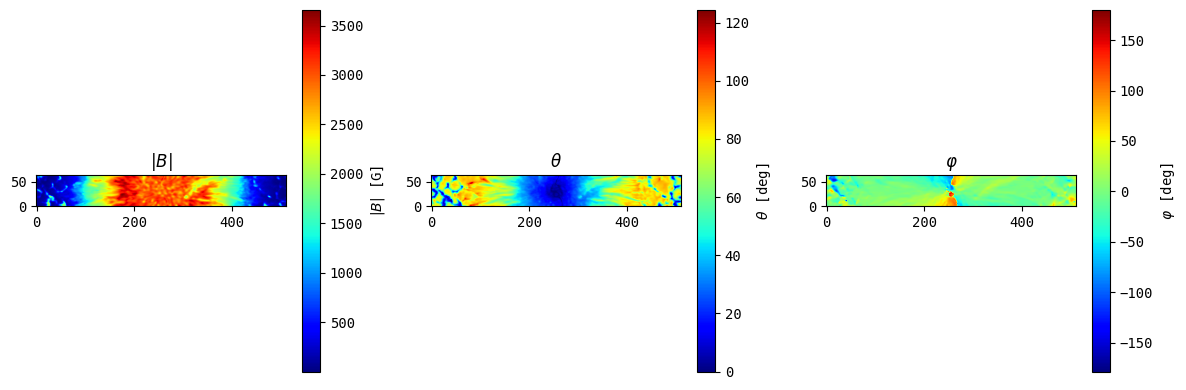

In [35]:
#prvi zadatak
#mape
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(B, origin='lower', cmap='jet')
plt.colorbar(label=r'$|B|$ [G]')
plt.title(r'$|B|$')

plt.subplot(132)
plt.imshow(theta, origin='lower', cmap='jet')
plt.colorbar(label=r'$\theta$ [deg]')
plt.title(r'$\theta$')

plt.subplot(133)
plt.imshow(phi, origin='lower', cmap='jet')
plt.colorbar(label=r'$\varphi$ [deg]')
plt.title(r'$\varphi$')

plt.tight_layout()
plt.show()

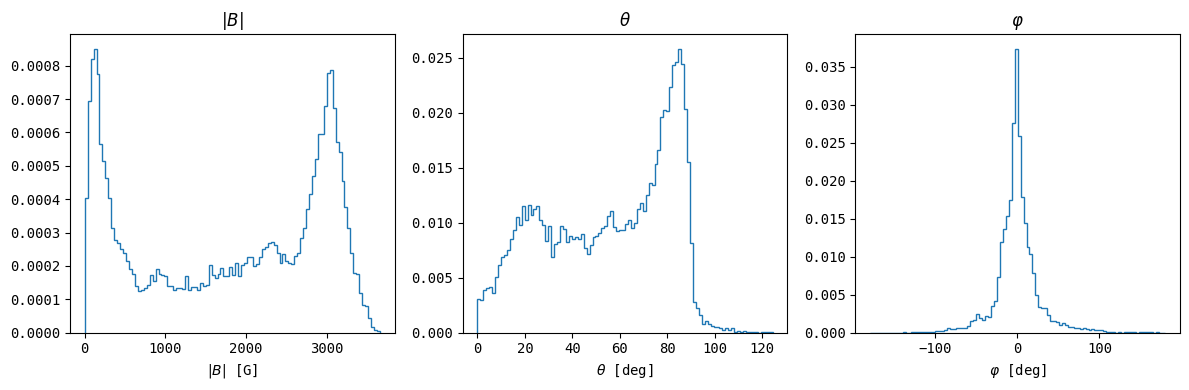

In [36]:
#histogrami 
plt.figure(figsize=(12,4))

plt.subplot(131)
plt.hist(B.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$|B|$ [G]')
plt.title(r'$|B|$')

plt.subplot(132)
plt.hist(theta.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$\theta$ [deg]')
plt.title(r'$\theta$')

plt.subplot(133)
plt.hist(phi.ravel(), bins=100, histtype='step', density=True)
plt.xlabel(r'$\varphi$ [deg]')
plt.title(r'$\varphi$')

plt.tight_layout()
plt.show()

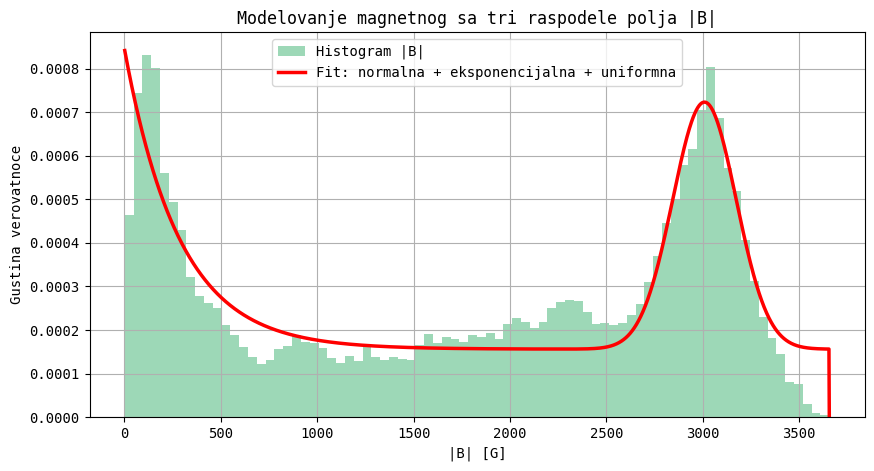

Parametri za B: 
w_norm = 0.2337347931372554
w_exp  = 0.19543596194751872
w_uni  = 0.5708292449152259
mu_B   = 3009.4476700393575
sigma_B = 164.52082610639619
tau_B  = 285.24769424785325


In [37]:
#drugi zadatak
#modelovanje magnetnog polja
B_min = np.min(B)
B_max = np.max(B)
B_range = B_max - B_min
hist_B, bins_B = np.histogram(B, bins=80, density=True)
x_B = 0.5 * (bins_B[:-1] + bins_B[1:])


def B_fun(x, a_norm, a_exp, a_uni, mu, sigma, tau):
    suma = a_norm + a_exp + a_uni
    w_norm = a_norm / suma
    w_exp = a_exp / suma
    w_uni = a_uni / suma

    return (w_norm * norm.pdf(x, loc=mu, scale=sigma) + w_exp * expon.pdf(x, loc=B_min,
                                                                          scale=tau) + w_uni * uniform.pdf(x, loc=B_min,
                                                                                                           scale=B_range))


p_B = [0.40, 0.35, 0.25, 2950, 200, 250]

bounds_B = ([0.01, 0.01, 0.01, 2000, 50, 20],
            [5.00, 5.00, 5.00, 3600, 800, 1500])

B_par, _ = curve_fit(B_fun, x_B, hist_B, p0=p_B, bounds=bounds_B, maxfev=50000)

x = np.linspace(B_min, B_max, 2000)

plt.figure(figsize=(10, 5))
plt.hist(B.ravel(), bins=80, density=True, alpha=0.5, color='mediumseagreen', label='Histogram |B|')
plt.plot(x, B_fun(x, *B_par), linewidth=2.5,color='red', label='Fit: normalna + eksponencijalna + uniformna')
plt.xlabel('|B| [G]')
plt.ylabel('Gustina verovatnoce')
plt.title('Modelovanje magnetnog sa tri raspodele polja |B|')
plt.legend()
plt.grid()
plt.show()

a_norm, a_exp, a_uni, mu_B, sigma_B, tau_B = B_par

suma = a_norm + a_exp + a_uni
w_norm_B = a_norm / suma
w_exp_B = a_exp / suma
w_uni_B = a_uni / suma

print("Parametri za B: ")
print("w_norm =", w_norm_B)
print("w_exp  =", w_exp_B)
print("w_uni  =", w_uni_B)
print("mu_B   =", mu_B)
print("sigma_B =", sigma_B)
print("tau_B  =", tau_B)

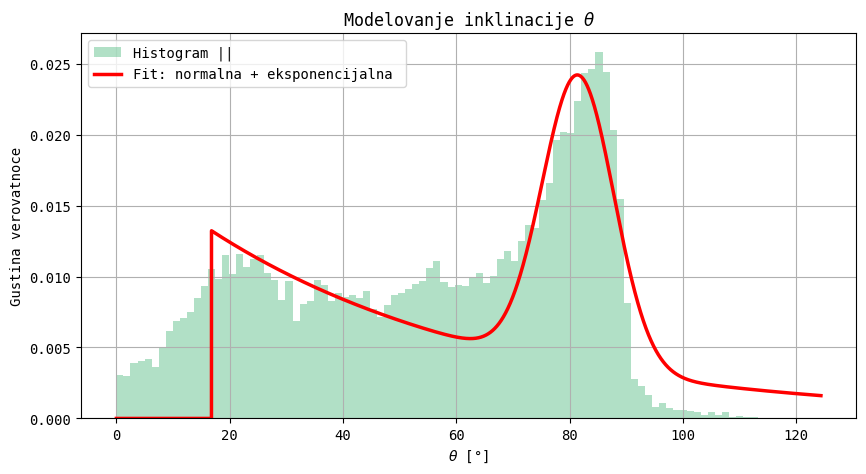

In [38]:
#modelovanje inklinacije
theta = theta.ravel()
theta = theta[np.isfinite(theta)]
theta_min = np.min(theta)
theta_max = np.max(theta)
theta_range = theta_max - theta_min
hist_theta, bins_theta = np.histogram(theta, bins=100, density=True)
x_theta = 0.5 * (bins_theta[:-1] + bins_theta[1:])

def theta_fun(x, b_norm, b_exp, mu, sigma,loc_exp,tau):
    suma = b_norm + b_exp
    w_norm = b_norm / suma
    w_exp = b_exp / suma

    return (w_norm * norm.pdf(x, loc=mu, scale=sigma) + w_exp * expon.pdf(x, loc=loc_exp, scale=tau))

p_theta = [0.5,0.5, np.mean(theta),np.std(theta),theta_min,np.std(theta)]

theta_par, _ = curve_fit(theta_fun,x_theta,hist_theta,p0=p_theta,maxfev=2000)

x = np.linspace(theta_min, theta_max, 20000)

plt.figure(figsize=(10, 5))
plt.hist(theta, bins=100, density=True, alpha=0.4, color='mediumseagreen', label='Histogram ||')
plt.plot(x,theta_fun(x, *theta_par),linewidth=2.5,color='red', label='Fit: normalna + eksponencijalna ')
plt.xlabel(r'$\theta$ [°]')
plt.ylabel('Gustina verovatnoce')
plt.title(r'Modelovanje inklinacije $\theta$')
plt.legend()
plt.grid()
plt.show()

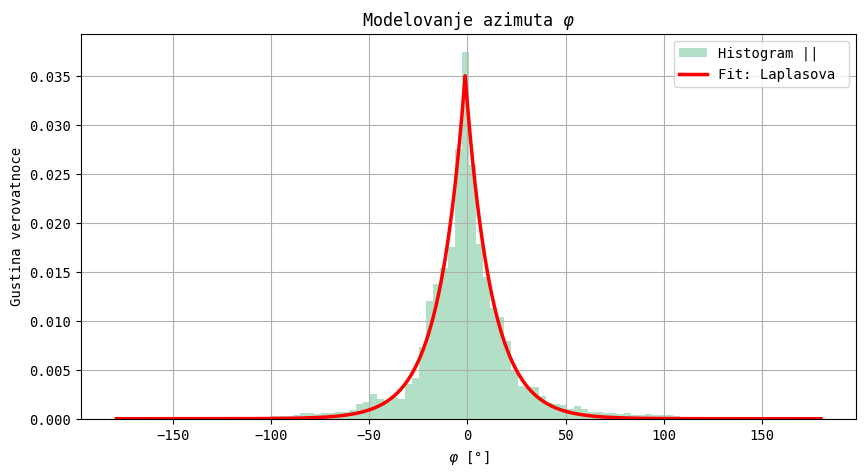

In [39]:
#modelovanje azimuta
phi = np.degrees(data['az'])
phi = phi.ravel()
phi = phi[np.isfinite(phi)]
phi_min = np.min(phi)
phi_max = np.max(phi)
phi_range = phi_max - phi_min
hist_phi, bins_phi = np.histogram(phi, bins=100, density=True)
x_phi = 0.5 * (bins_phi[:-1] + bins_phi[1:])

def phi_fun(x, c_lap,loc_lap,tau):
    w_lap = c_lap
    return (w_lap * laplace.pdf(x, loc=loc_lap, scale=tau))

p_phi = [1.0, x_phi[np.argmax(hist_phi)], np.std(phi)]

phi_par, _ = curve_fit(phi_fun,x_phi,hist_phi,p0=p_phi,maxfev=2000)

x = np.linspace(phi_min, phi_max, 20000)

plt.figure(figsize=(10, 5))
plt.hist(phi, bins=100, density=True, alpha=0.4, color='mediumseagreen', label='Histogram ||')
plt.plot(x,phi_fun(x, *phi_par), linewidth=2.5, color='red', label='Fit: Laplasova ')
plt.xlabel(r'$\varphi$ [°]')
plt.ylabel('Gustina verovatnoce')
plt.title(r'Modelovanje azimuta $\varphi$')
plt.legend()
plt.grid()
plt.show()

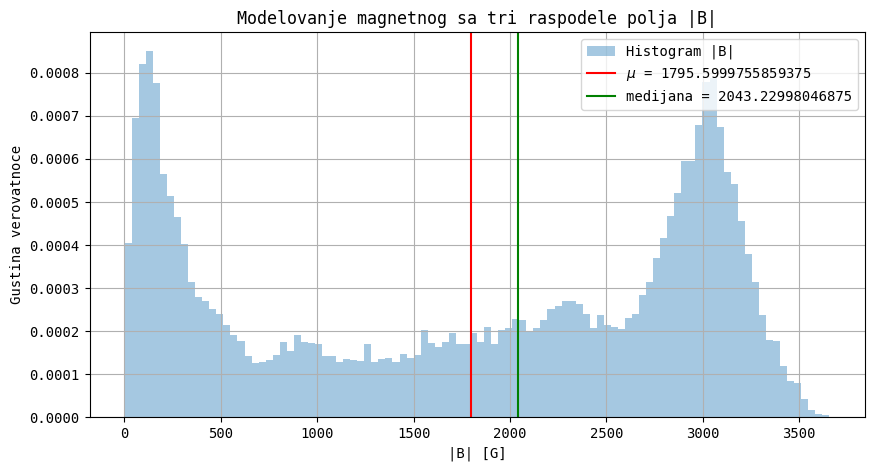

Srednja vrednost: 1795.60
Medijana:2043.23
Varijansa:1354138.38
Standardna devijacija: 1163.67
Skewness: -0.24
Kurtosis: -1.50
Mod: 190.87
25. percentil: 511.98
50. percentil: 2043.23
75. percentil: 2919.10
Devijacija:2407.12


In [40]:
#treci zadatak
#koristan je i bez faktora renormalizacije

# B #
sv = np.mean(B)
medijana = np.median(B)
varijansa = np.var(B)
stdev = np.std(B)
s = skew(B.ravel())
k = kurtosis(B.ravel())
moda = mode(B.ravel())
q25, q50, q75 = np.percentile(B, [25, 50, 75])
devG=q75-q25

plt.figure(figsize=(10, 5))
plt.hist(B.ravel(), bins=100, density=True, alpha=0.4, label='Histogram |B|')
plt.axvline(sv, color='red', linestyle='-', label=r'$\mu$ = {}'.format(round(sv, 2)))
plt.axvline(medijana, color='green', linestyle='-', label=r'medijana = {}'.format(round(medijana, 2)))
plt.xlabel('|B| [G]')
plt.ylabel('Gustina verovatnoce')
plt.title('Modelovanje magnetnog sa tri raspodele polja |B|')
plt.legend()
plt.grid()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Skewness: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")

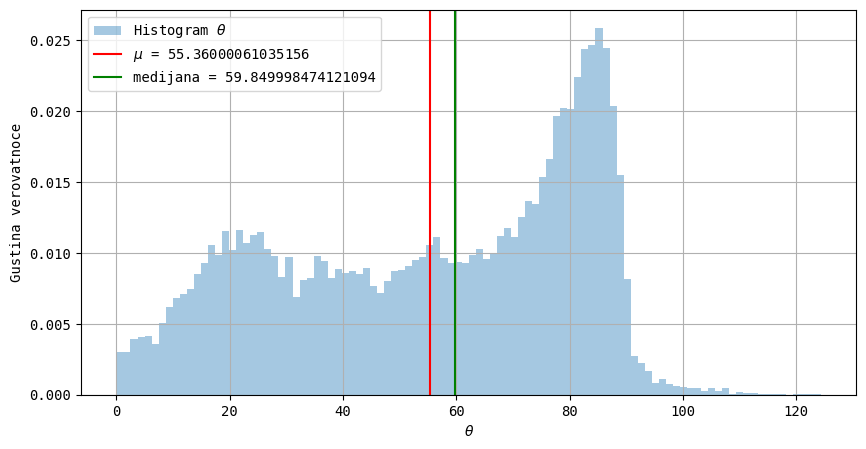

Srednja vrednost: 55.36
Medijana:59.85
Varijansa:691.98
Standardna devijacija: 26.31
Skewness: -0.34
Kurtosis: -1.18
Mod: 0.00
25. percentil: 31.78
50. percentil: 59.85
75. percentil: 79.48
Devijacija:47.70


In [41]:
# THETA #
sv = np.mean(theta)
medijana = np.median(theta)
varijansa = np.var(theta)
stdev = np.std(theta)
s = skew(theta)
k = kurtosis(theta)
moda = mode(theta)
q25, q50, q75 = np.percentile(theta, [25, 50, 75])
devG=q75-q25

plt.figure(figsize=(10, 5))
plt.hist(theta, bins=100, density=True, alpha=0.4, label=r'Histogram $\theta$')
plt.axvline(sv, color='red', linestyle='-', label=r'$\mu$ = {}'.format(round(sv, 2)))
plt.axvline(medijana, color='green', linestyle='-', label=r'medijana = {}'.format(round(medijana, 2)))
plt.xlabel(r'$\theta $')
plt.ylabel('Gustina verovatnoce')
plt.title('')
plt.legend()
plt.grid()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Skewness: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")

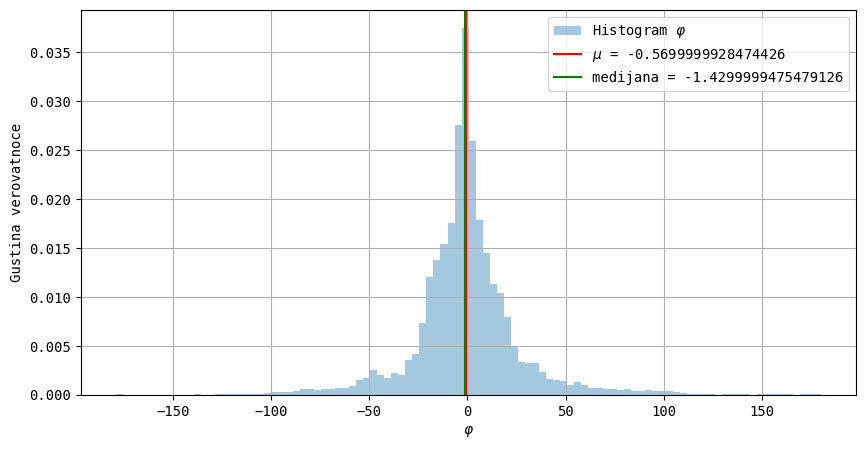

Srednja vrednost: -0.57
Medijana:-1.43
Varijansa:719.21
Standardna devijacija: 26.82
Skewness: 0.44
Kurtosis: 5.74
Mod: -76.73
25. percentil: -11.84
50. percentil: -1.43
75. percentil: 9.26
Devijacija:21.10


In [42]:
# PHI #
sv = np.mean(phi)
medijana = np.median(phi)
varijansa = np.var(phi)
stdev = np.std(phi)
s = skew(phi)
k = kurtosis(phi)
moda = mode(phi)
q25, q50, q75 = np.percentile(phi, [25, 50, 75])
devG=q75-q25

plt.figure(figsize=(10, 5))
plt.hist(phi, bins=100, density=True, alpha=0.4, label=r'Histogram $\varphi$')
plt.axvline(sv, color='red', linestyle='-', label=r'$\mu$ = {}'.format(round(sv, 2)))
plt.axvline(medijana, color='green', linestyle='-', label=r'medijana = {}'.format(round(medijana, 2)))
plt.xlabel(r'$\varphi$')
plt.ylabel('Gustina verovatnoce')
plt.title('')
plt.legend()
plt.grid()
plt.show()

print(f"Srednja vrednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Skewness: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")

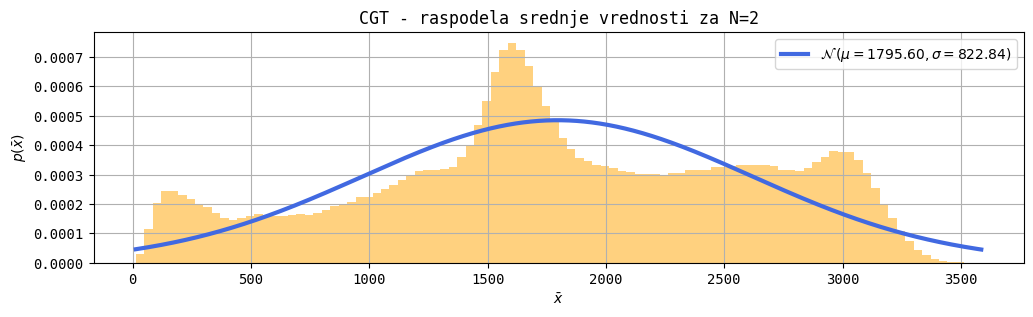

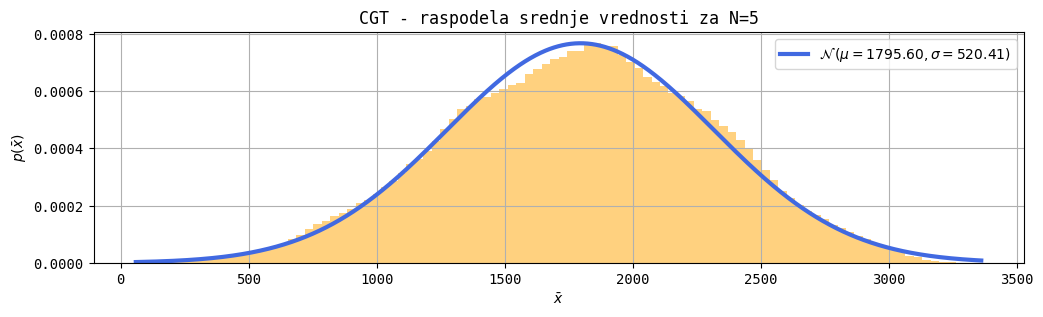

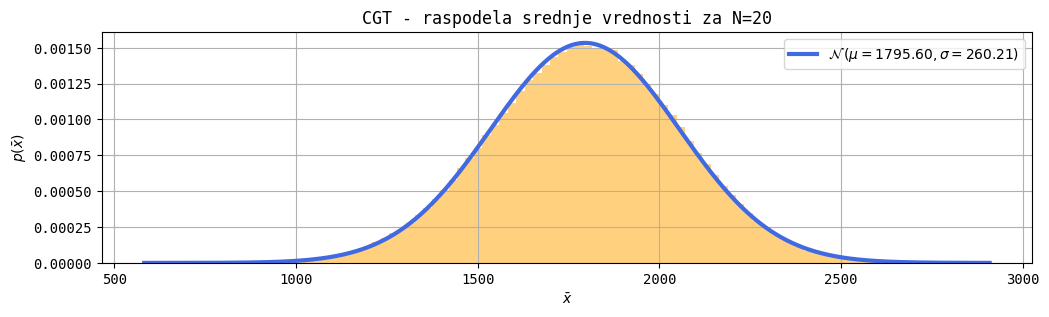

In [43]:
#cetvrti zadatak

#CGT B
N = [ 2, 5, 20]
M = int(1e6)

p = B
p = p.ravel()
p = p[np.isfinite(p)]

xu = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xu[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='orange',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='royalblue',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()

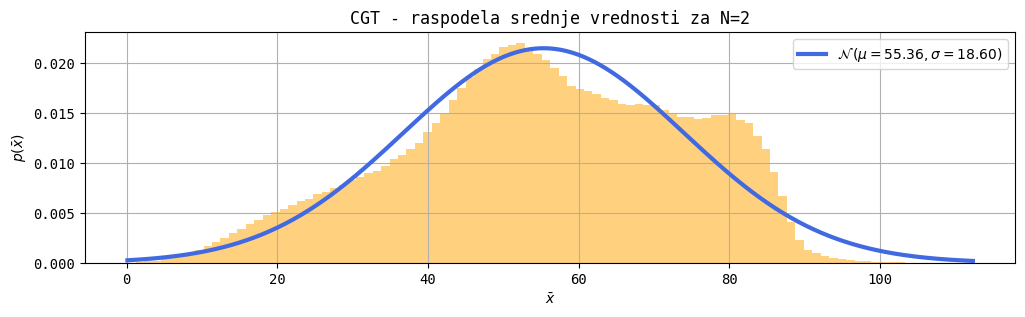

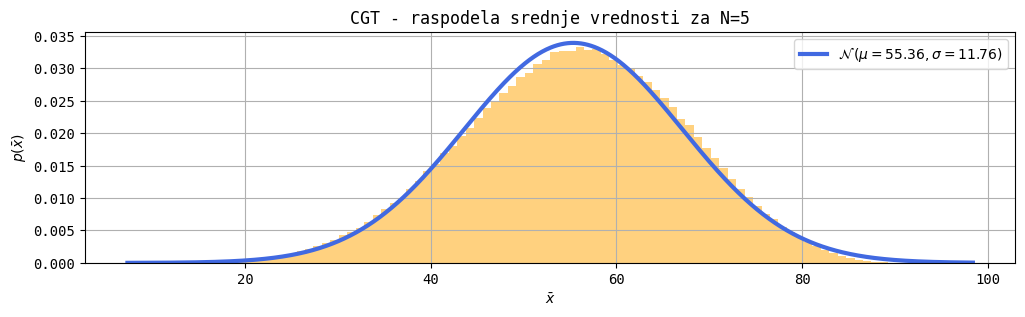

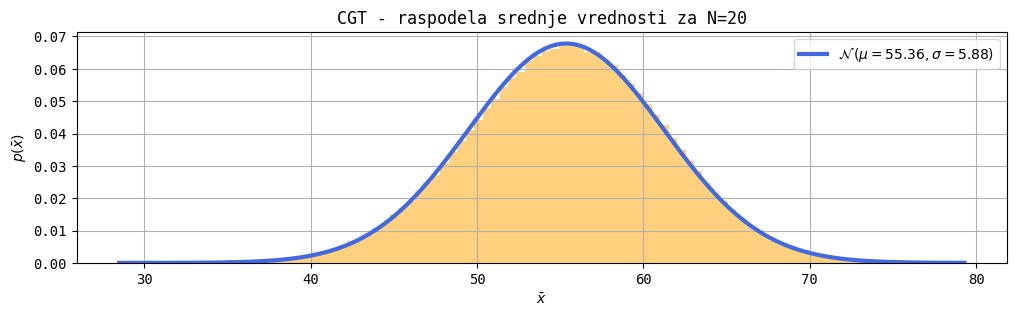

In [44]:
#CGT THETA
N = [ 2, 5, 20]
M = int(1e6)

p = theta
p = p.ravel()
p = p[np.isfinite(p)]

xu = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xu[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='orange',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='royalblue',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()

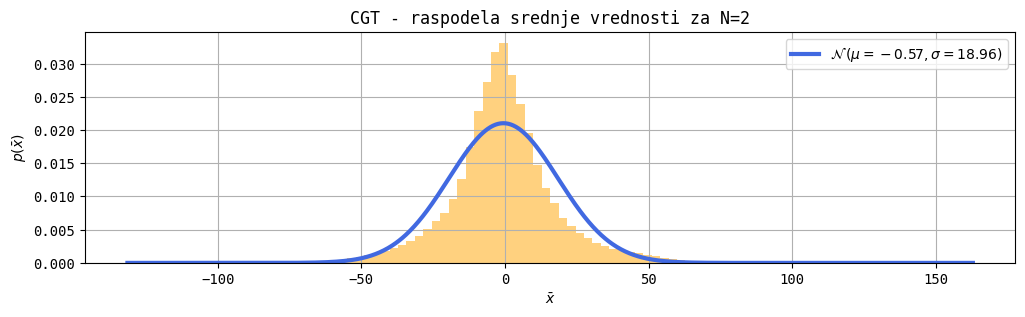

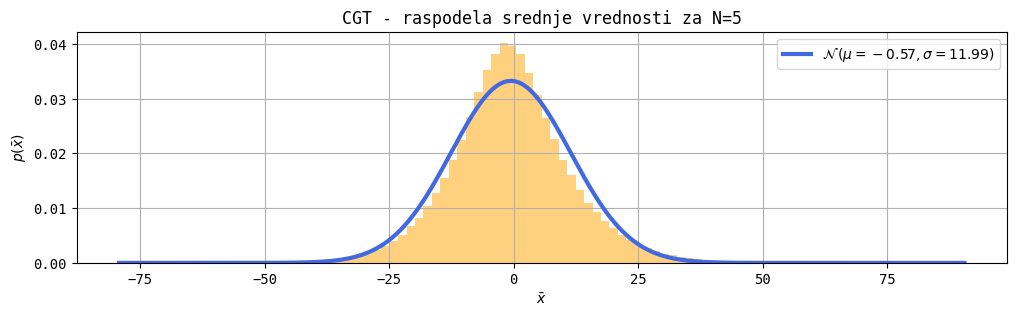

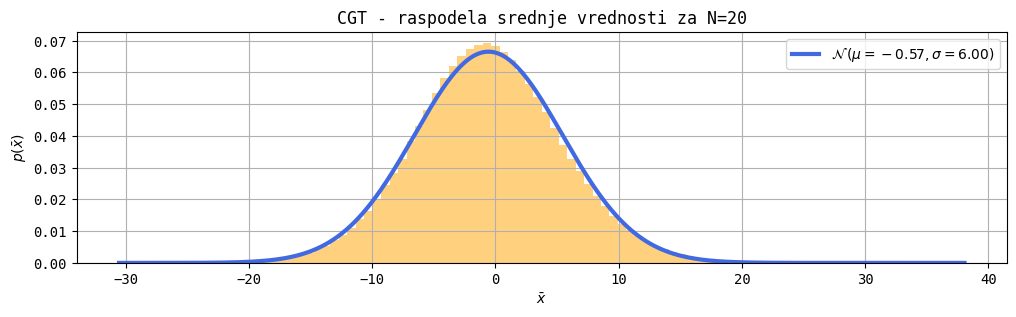

In [45]:
#CGT PHI
N = [ 2, 5, 20]
M = int(1e6)

p = phi
p = p.ravel()
p = p[np.isfinite(p)]

xu = np.random.choice(p, size=(max(N), M), replace=True)

for i in range(len(N)):
    x_i = xu[:N[i], :].mean(axis=0)
    plt.figure(figsize=(12, 3))
    plt.hist(x_i,bins=100,histtype='stepfilled',density=True,color='orange',alpha=0.5)
    mu = np.mean(p)
    sigma = np.std(p) / np.sqrt(N[i])
    dist = norm(mu, sigma)
    x_pdf = np.linspace(np.min(x_i), np.max(x_i), 1000)
    plt.plot(x_pdf,dist.pdf(x_pdf),color='royalblue',lw=3,label=rf'$\mathcal{{N}}\,(\mu={mu:.2f}, \sigma={sigma:.2f})$')
    plt.xlabel(r'$\bar{x}$')
    plt.ylabel(r'$p(\bar{x})$')
    plt.title(rf'CGT - raspodela srednje vrednosti za N={N[i]}')
    plt.legend()
    plt.grid()
    plt.show()

In [46]:
#peti zadatak
mu0=4*np.pi*1e-7
B1= B * 1e-4
P= B1**2 / (2*mu0)
s_B = np.std(B1,ddof=1)
B_srednje = np.mean(B1)
dP_dB = B_srednje / mu0
s_P_propagacija = s_B * abs(dP_dB)
s_P_direktno = np.std(P,ddof=1)

apsolutno_odstupanje = abs(s_P_propagacija - s_P_direktno)
relativno_odstupanje = apsolutno_odstupanje / s_P_direktno

print("s_P propagacijom =", s_P_propagacija)
print("s_P direktno iz P =", s_P_direktno)

print("Apsolutno odstupanje =", apsolutno_odstupanje)
print("Relativno odstupanje =", relativno_odstupanje)

s_P propagacijom = 16627.889580775427
s_P direktno iz P = 15740.621
Apsolutno odstupanje = 887.268487025427
Relativno odstupanje = 0.05636807351761536
